# Capitolo 2 — Il percettrone e la prima rete da zero
Solo NumPy: neurone, discesa del gradiente, AND, XOR, strato nascosto e backpropagation.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import numpy as np
import matplotlib.pyplot as plt
fissa_seme(42)

## 2.1 Il neurone artificiale

In [2]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def neurone(x, w, b):
    z = x @ w + b
    return sigmoide(z)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_and = np.array([0, 0, 0, 1], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

Pesi scelti a mano: la AND si può fare, il punto è farla scoprire alla rete.

In [3]:
print(neurone(X, np.array([1.0, 1.0]), -1.5))
print(neurone(X, np.array([10.0, 10.0]), -15.0))

[0.18242552 0.37754067 0.37754067 0.62245933]
[3.05902227e-07 6.69285092e-03 6.69285092e-03 9.93307149e-01]


## 2.3 Il percettrone impara la AND

In [4]:
def addestra_neurone(X, y, tasso=0.5, epoche=2000):
    w = np.random.randn(2) * 0.1
    b = 0.0
    storia = []
    for epoca in range(epoche):
        y_hat = sigmoide(X @ w + b)                 # forward
        perdita = np.mean((y_hat - y) ** 2)
        storia.append(perdita)
        delta = 2 * (y_hat - y) / len(y) * y_hat * (1 - y_hat)   # backward
        grad_w = X.T @ delta
        grad_b = delta.sum()
        w -= tasso * grad_w                         # aggiornamento
        b -= tasso * grad_b
    return w, b, storia

fissa_seme(42)
w, b, storia = addestra_neurone(X, y_and)
print("Uscite:", np.round(sigmoide(X @ w + b), 3))
print("Pesi:", np.round(w, 2), " Bias:", round(b, 2))
print("Perdita finale:", round(storia[-1], 4))

Uscite: [0.001 0.082 0.082 0.902]
Pesi: [4.64 4.64]  Bias: -7.06
Perdita finale: 0.0057


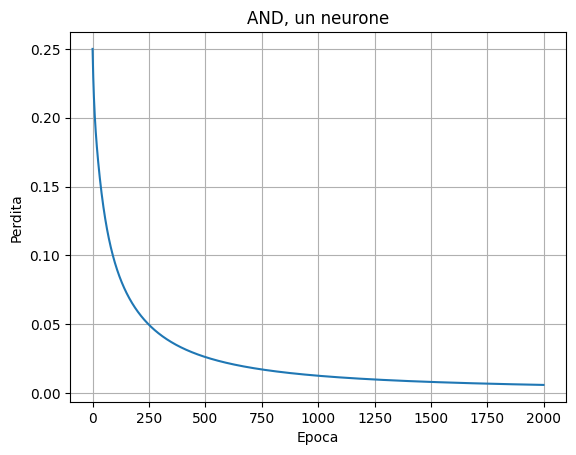

In [5]:
plt.plot(storia)
plt.xlabel("Epoca"); plt.ylabel("Perdita"); plt.grid(True); plt.title("AND, un neurone")
plt.show()

Esperimento: cambiare `tasso` (0.05, 0.5, 5) e osservare la curva.

In [6]:
for tasso in (0.05, 0.5, 5):
    fissa_seme(42)
    w, b, storia = addestra_neurone(X, y_and, tasso=tasso)
    print(f"tasso {tasso}: uscite {np.round(sigmoide(X @ w + b), 3)}  perdita {storia[-1]:.4f}")

tasso 0.05: uscite [0.053 0.256 0.256 0.679]  perdita 0.0593


tasso 0.5: uscite [0.001 0.082 0.082 0.902]  perdita 0.0057
tasso 5: uscite [0.    0.023 0.023 0.972]  perdita 0.0005


## 2.4 Il limite: la XOR

In [7]:
fissa_seme(42)
w, b, storia = addestra_neurone(X, y_xor)
print("Uscite:", np.round(sigmoide(X @ w + b), 3))
print("Perdita finale:", round(storia[-1], 4))

Uscite: [0.5 0.5 0.5 0.5]
Perdita finale: 0.25


## 2.5 Lo strato nascosto e la backpropagation

In [8]:
def addestra_rete(X, y, nascosti=2, tasso=0.5, epoche=5000):
    W1 = np.random.randn(2, nascosti)
    b1 = np.zeros(nascosti)
    W2 = np.random.randn(nascosti)
    b2 = 0.0
    storia = []
    for epoca in range(epoche):
        h = sigmoide(X @ W1 + b1)                       # forward
        y_hat = sigmoide(h @ W2 + b2)
        storia.append(np.mean((y_hat - y) ** 2))
        delta2 = 2 * (y_hat - y) / len(y) * y_hat * (1 - y_hat)   # backward, uscita
        grad_W2 = h.T @ delta2
        grad_b2 = delta2.sum()
        delta1 = np.outer(delta2, W2) * h * (1 - h)     # backward, strato nascosto
        grad_W1 = X.T @ delta1
        grad_b1 = delta1.sum(axis=0)
        W1 -= tasso * grad_W1;  b1 -= tasso * grad_b1
        W2 -= tasso * grad_W2;  b2 -= tasso * grad_b2
    return (W1, b1, W2, b2), storia

def valuta_rete(parametri):
    W1, b1, W2, b2 = parametri
    h = sigmoide(X @ W1 + b1)
    return sigmoide(h @ W2 + b2), h

## 2.6 La XOR risolta (quasi al primo colpo)
Con due neuroni nascosti e seme 42 la rete si ferma in un minimo locale.

In [9]:
fissa_seme(42)
parametri, storia2 = addestra_rete(X, y_xor, nascosti=2)
uscite, h = valuta_rete(parametri)
print("Uscite:", np.round(uscite, 3), " Perdita finale:", round(storia2[-1], 4))

Uscite: [0.044 0.497 0.959 0.502]  Perdita finale: 0.1273


In [10]:
fissa_seme(42)
parametri, storia4 = addestra_rete(X, y_xor, nascosti=4)
uscite, h = valuta_rete(parametri)
print("Uscite:", np.round(uscite, 3), " Perdita finale:", round(storia4[-1], 4))
print("Attivazioni nascoste:\n", np.round(h, 2))
print("W2:", np.round(parametri[2], 2))

Uscite: [0.03  0.96  0.956 0.051]  Perdita finale: 0.0018
Attivazioni nascoste:
 [[0.8  0.6  0.09 0.11]
 [0.12 0.02 0.65 0.98]
 [1.   0.83 0.18 0.98]
 [0.97 0.07 0.81 1.  ]]
W2: [-6.89  4.92 -4.16  8.28]


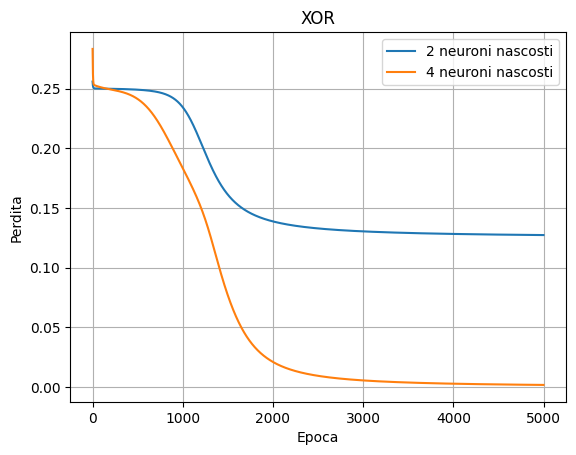

In [11]:
plt.plot(storia2, label="2 neuroni nascosti")
plt.plot(storia4, label="4 neuroni nascosti")
plt.xlabel("Epoca"); plt.ylabel("Perdita"); plt.legend(); plt.grid(True); plt.title("XOR")
plt.show()

Esperimento: semi diversi con 2 neuroni nascosti — alcuni convergono, altri no.

In [12]:
for seme in range(5):
    fissa_seme(seme)
    parametri, s = addestra_rete(X, y_xor, nascosti=2)
    print(f"seme {seme}: uscite {np.round(valuta_rete(parametri)[0], 2)}  perdita {s[-1]:.4f}")

seme 0: uscite [0.03 0.5  0.96 0.5 ]  perdita 0.1268
seme 1: uscite [0.04 0.96 0.96 0.06]  perdita 0.0022


seme 2: uscite [0.04 0.96 0.96 0.04]  perdita 0.0018
seme 3: uscite [0.04 0.95 0.96 0.04]  perdita 0.0017


seme 4: uscite [0.04 0.95 0.95 0.05]  perdita 0.0020
